In [1]:
#import requests
#link = 'https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip'
#response = requests.get(link)
#with open(r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_data', 'wb') as file:
 #   file.write(response.content)

In [2]:
#import zipfile

#zip_path = r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_data.zip'
#destination_path = r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_data'
#with zipfile.ZipFile(zip_path, 'r') as file:
#    file.extractall(destination_path)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm


In [4]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [5]:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
train_image = Image.open(r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_data\data\train\curly\00cbad1ffe22d900018e5a2e7376daed4.jpg')

In [7]:
npv = np.array(train_image)

In [8]:
npv.shape

(768, 614, 3)

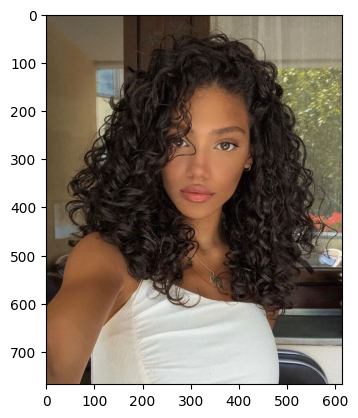

In [9]:
plt.imshow(npv)

In [10]:
train_data = datasets.ImageFolder(r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_data\data\train', transform = transforms.Compose([transforms.Resize((200, 200)), transforms.ToTensor()]))
test_data = datasets.ImageFolder(r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_data\data\test', transform = transforms.ToTensor())

In [11]:
image, label = next(iter(train_data))

In [12]:
num_classes = len(train_data.classes)

In [13]:
num_classes

2

In [14]:
image.shape

torch.Size([3, 200, 200])

In [40]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size = (3, 3))
        self.pool = nn.MaxPool2d(kernel_size = (2, 2))
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 99 * 99, 64)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.sigmoid(x)
        return x

In [41]:
model = Net()

In [43]:
from torchsummary import summary
summary(model, input_size = (3, 200,200))  

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 198, 198]             896
         MaxPool2d-2           [-1, 32, 99, 99]               0
           Flatten-3               [-1, 313632]               0
            Linear-4                   [-1, 64]      20,072,512
            Linear-5                    [-1, 1]              65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.46
Forward/backward pass size (MB): 14.36
Params size (MB): 76.57
Estimated Total Size (MB): 91.39
----------------------------------------------------------------


In [46]:
sum([p.numel() for p in model.parameters()])

20073473

In [47]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])

In [48]:
train_data = datasets.ImageFolder(r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_data\data\train', transform = train_transforms)
test_data = datasets.ImageFolder(r'C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_data\data\test', transform = train_transforms)

In [49]:
train_loader = DataLoader(train_data, batch_size = 20, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 20, shuffle = False)

Dataset ImageFolder
    Number of datapoints: 800
    Root location: C:\Users\Abdullahi Mujaheed\Desktop\mlzoom\mlzoomcamp\hair_data\data\train
    StandardTransform
Transform: Compose(
               Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [77]:
'''image, label = next(iter(train_loader))
'''

'image, label = next(iter(train_loader))\n'

In [66]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [68]:
optimizer = optim.SGD(model.parameters(), lr = 0.01, momentum= .8)
from torch.nn import BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()

In [89]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'test_acc': [], 'test_loss': []}

In [93]:

for epoch in tqdm(range(num_epochs)):
    model.train()
    running_loss = 0.0
    correct_train = 0.0
    total_train = .0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()* images.size(0)
        predicted = (output > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    epoch_loss = running_loss/ len(train_loader.dataset)
    epoch_acc = correct_train/total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    
    print(f"Epoch {epoch+1}/{num_epochs}", f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

 10%|█         | 1/10 [00:25<03:50, 25.62s/it]

Epoch 1/10 Loss: 0.6931, Acc: 0.5125


 20%|██        | 2/10 [00:53<03:35, 26.99s/it]

Epoch 2/10 Loss: 0.6931, Acc: 0.5125


 30%|███       | 3/10 [01:21<03:11, 27.29s/it]

...

Epoch 8/10 Loss: 0.6930, Acc: 0.5125


 90%|█████████ | 9/10 [04:16<00:29, 29.26s/it]

Epoch 9/10 Loss: 0.6929, Acc: 0.5125


100%|██████████| 10/10 [04:46<00:00, 28.63s/it]

Epoch 10/10 Loss: 0.6851, Acc: 0.5413


In [94]:
model.eval()
test_running_loss = 0.0
correct_test = 0.0
total_test = 0.0

In [97]:
with torch.no_grad():
    for epoch in tqdm(range(10)):
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            output = model(images)
            loss = criterion(output, labels)

            test_running_loss += loss.item() * images.size(0)
            predicted = (output> 0.5).float()
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
        
        epoch_test_loss = test_running_loss/ len(test_loader.dataset)
        epoch_test_acc = correct_test/ total_test
        history['test_acc'].append(epoch_test_acc)
        history['test_loss'].append(epoch_test_loss)

        
        print(f"Epoch {epoch+1}/{num_epochs}", f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")

 10%|█         | 1/10 [00:03<00:35,  3.90s/it]

Epoch 1/10 Loss: 0.6851, Acc: 0.5413


 20%|██        | 2/10 [00:07<00:30,  3.81s/it]

Epoch 2/10 Loss: 0.6851, Acc: 0.5413


 30%|███       | 3/10 [00:11<00:27,  3.94s/it]

...

Epoch 8/10 Loss: 0.6851, Acc: 0.5413


 90%|█████████ | 9/10 [00:36<00:04,  4.27s/it]

Epoch 9/10 Loss: 0.6851, Acc: 0.5413


100%|██████████| 10/10 [00:40<00:00,  4.01s/it]

Epoch 10/10 Loss: 0.6851, Acc: 0.5413


In [111]:
n = np.array(history['acc'])

In [113]:
np.median(n)

np.float64(0.5125)

In [119]:
history.keys()

dict_keys(['acc', 'loss', 'test_acc', 'test_loss'])

In [116]:
l = np.array(history['loss'])
np.std(l)

np.float64(0.0022992627047207135)

In [124]:
m = np.array(history['test_loss'])
m.mean()

np.float64(4.077218843929803)

In [131]:
m

array([0.67953647, 1.35907295, 2.03860942, 2.7181459 , 3.39768237,
       4.07721884, 4.75675532, 5.43629179, 6.11582827, 6.79536474,
       7.47490121])

In [127]:
history['test_loss']

[0.6795364739883005,
 1.359072947976601,
 2.038609421964902,
 2.718145895953202,
 3.397682369941503,
 4.077218843929804,
 4.7567553179181035,
 5.436291791906404,
 6.115828265894705,
 6.795364739883006,
 7.474901213871306]

In [128]:
a = np.array(history['test_acc'])

In [141]:
np.mean(a[:5, ])

np.float64(0.5174129353233831)